# Mounting/Remounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# UNZIP dataset

In [ ]:
!unzip "/content/drive/MyDrive/Animal dataset.zip" -d "/content/drive/MyDrive/dataset"

Archive:  /content/drive/MyDrive/Animal dataset.zip
replace /content/drive/MyDrive/dataset/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Check what colab see

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/dataset"))

['translate.py', 'training_set', 'test_set', 'single_prediction', 'raw-img']


In [ ]:
data_dir = "/content/drive/MyDrive/dataset/raw-img"

In [ ]:
import tensorflow as tf

batch_size = 32
img_size = (224, 224)

# Dataset_from_directory

In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 26179 files belonging to 10 classes.


# Class names

In [ ]:
class_names = dataset.class_names
print("Classes:", class_names)

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# Data spliting

In [ ]:
total_batches = tf.data.experimental.cardinality(dataset).numpy()

train_size = int(0.7 * total_batches)
val_size = int(0.2 * total_batches)
test_size = total_batches - train_size - val_size

train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)

val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print("Train:", train_size)
print("Val:", val_size)
print("Test:", test_size)

Train: 573
Val: 163
Test: 83


#  Display 5 sample images for each class with their labels.

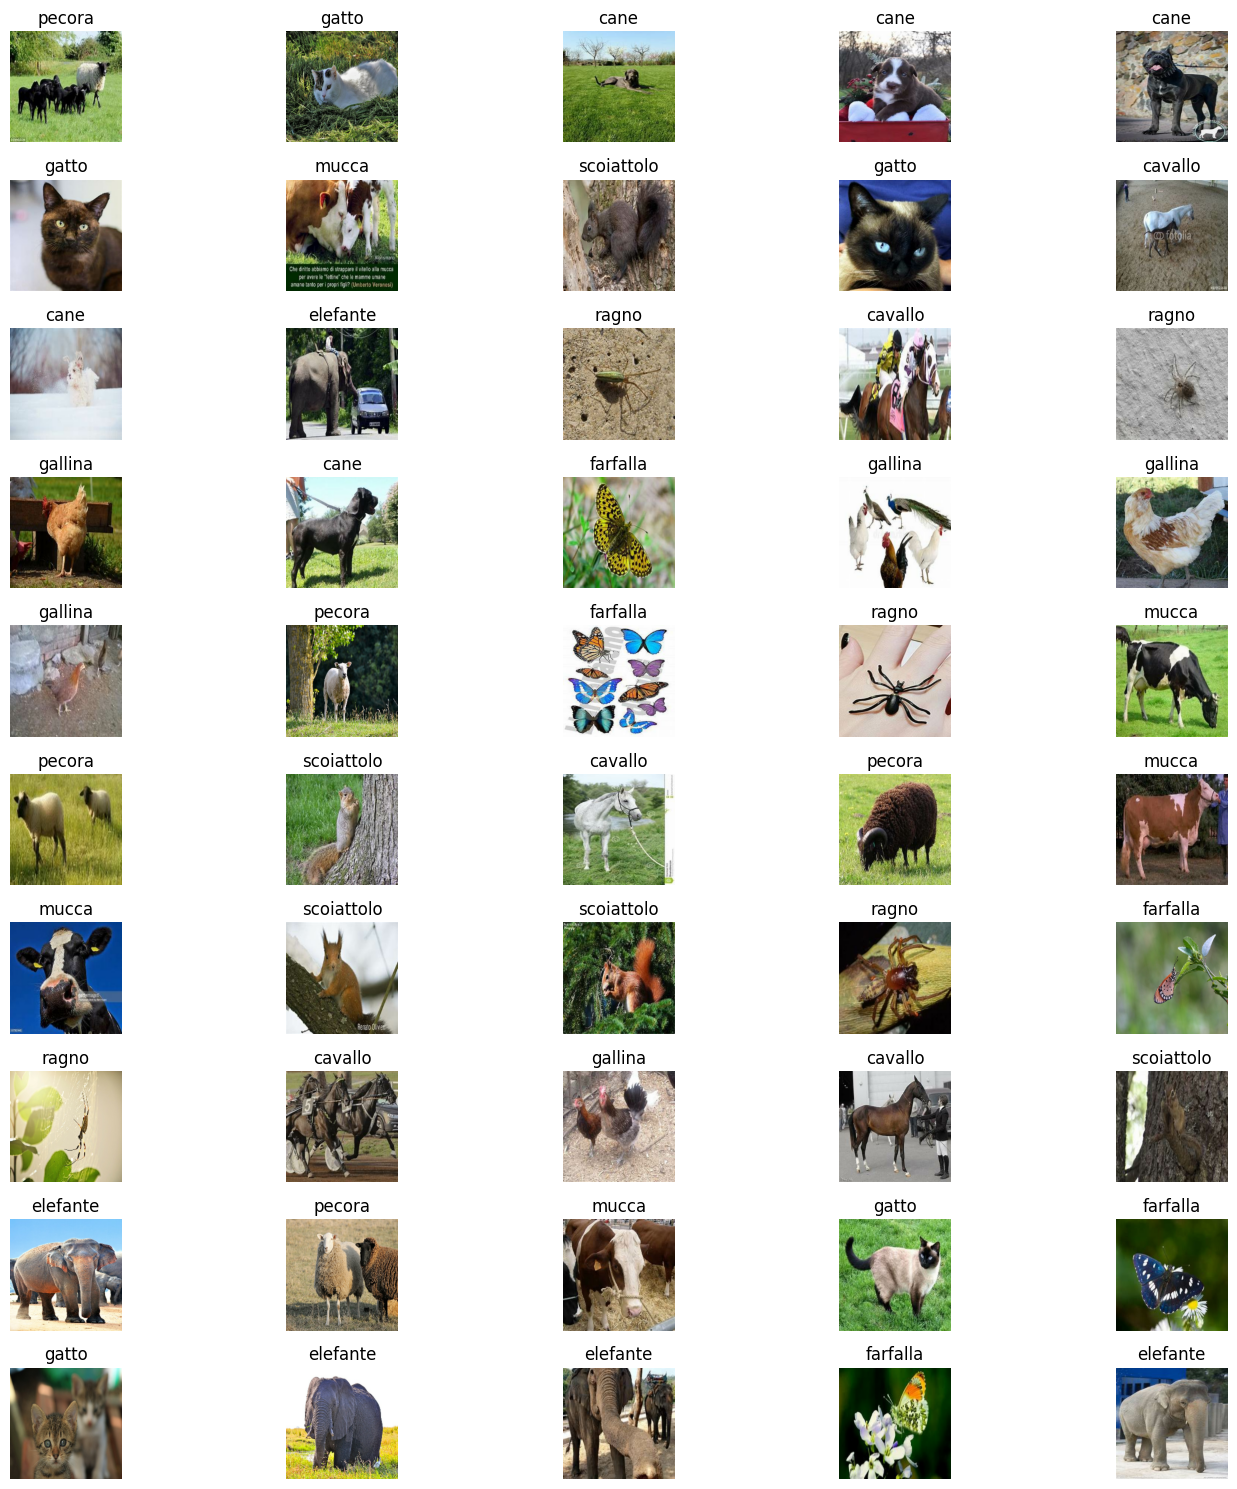

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

class_count = {name: 0 for name in class_names}
plot_index = 1

for images, labels in train_ds.unbatch():

    label_name = class_names[labels.numpy()]

    if class_count[label_name] < 5:
        plt.subplot(10, 5, plot_index)
        plt.imshow(images.numpy().astype("uint8"))
        plt.title(label_name)
        plt.axis("off")

        class_count[label_name] += 1
        plot_index += 1

    # stop when we have 5 images for all classes
    if all(v == 5 for v in class_count.values()):
        break

plt.tight_layout()
plt.show()

# Data Augmentation


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.GaussianNoise(0.1)
])

# Model Building

Load MobileNet (Pretrained ImageNet)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze Base Model

In [ ]:
base_model.trainable = False

Build Model Inputs

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

Apply Augmentation (ONLY training effect)

In [ ]:
x = data_augmentation(inputs)

Preprocessing + Base Model

In [ ]:
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)

Custom Top Layers

In [ ]:
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

Final Model

In [ ]:
model = tf.keras.Model(inputs, outputs)

Model Summary

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Why MobileNet was chosen

MobileNet was chosen because it is a lightweight and efficient deep learning model designed for mobile and low-computation environments. It uses depthwise separable convolutions, which significantly reduce the number of parameters and computation while maintaining good accuracy. This makes it suitable for wildlife classification tasks where computational resources may be limited.

# Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model (MAX 50 EPOCHS)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 162s 282ms/step - accuracy: 0.8389 - loss: 0.4812 - val_accuracy: 0.9525 - val_loss: 0.1514
Epoch 2/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 160s 279ms/step - accuracy: 0.8453 - loss: 0.4611 - val_accuracy: 0.9546 - val_loss: 0.1475
Epoch 3/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 161s 280ms/step - accuracy: 0.8502 - loss: 0.4488 - val_accuracy: 0.9521 - val_loss: 0.1508
Epoch 4/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 160s 279ms/step - accuracy: 0.8525 - loss: 0.4425 - val_accuracy: 0.9595 - val_loss: 0.1432
Epoch 5/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 159s 277ms/step - accuracy: 0.8575 - loss: 0.4290 - val_accuracy: 0.9572 - val_loss: 0.1373
Epoch 6/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 157s 274ms/step - accuracy: 0.8548 - loss: 0.4260 - val_accuracy: 0.9549 - val_loss: 0.1411
Epoch 7/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 159s 278ms/step - accuracy: 0.8620 - loss: 0.4171 - val_accuracy: 0.9498 - val_loss: 0.1513
Epoch 8/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 159s 278ms/step - accuracy: 0.8590 -

# Plot Loss (Training vs Validation) Accuracy Plot

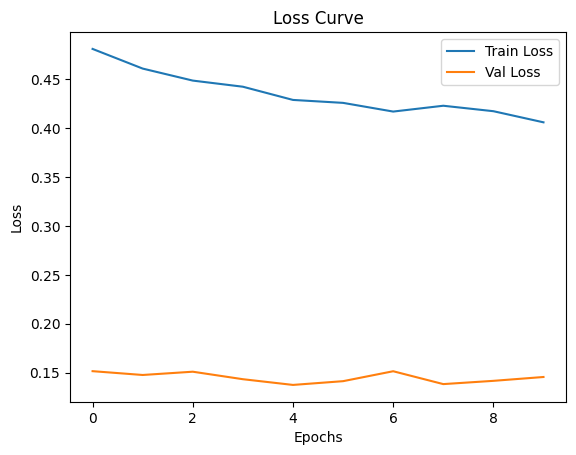

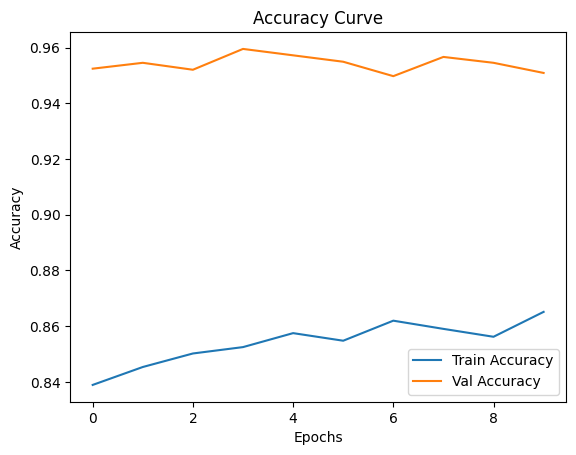

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Accurancy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Did overfitting occur?

No, overfitting did not occur in model. Overfitting happens when the model performs very well on training data but poorly on validation data, usually seen as training loss decreasing while validation loss increases, or training accuracy being much higher than validation accuracy. In the graphs, both training loss and validation loss are either decreasing or stable, and validation accuracy remains consistently high. There is no large gap between training and validation performance, which indicates that the model is generalizing well to unseen data rather than memorizing the training data.

# Final validation accuracy

The final validation accuracy is approximately 95–96%. This means that at the end of training, model correctly predicts about 95 out of 100 samples from unseen data. Such a high validation accuracy indicates strong model performance and suggests that the learned features are effective for making accurate predictions beyond the training dataset.

# Effect of Early Stopping

Early stopping is a technique used to stop training when the model stops improving on validation data. Its main purpose is to prevent overfitting and reduce unnecessary computation. In this case, early stopping likely monitored the validation loss and stopped training when it stopped decreasing significantly. This helps ensure that the model does not continue training to the point where it starts memorizing noise in the training data. As a result, it keeps the model at its best-performing state on unseen data while also saving time and computational resources.

# At which epoch did it stop?

From the graph, training appears to have stopped around epoch 9 or 10. This is where both the loss and accuracy curves stabilize, and there is no significant improvement afterward. Early stopping would typically trigger at this point because the validation loss is no longer improving meaningfully, indicating that further training would not provide better results.

# Get class names

In [ ]:
class_names = dataset.class_names

# Take 5 test images

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_images = []
test_labels = []

for images, labels in test_ds.unbatch().take(5):
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

# Prediction Loop

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


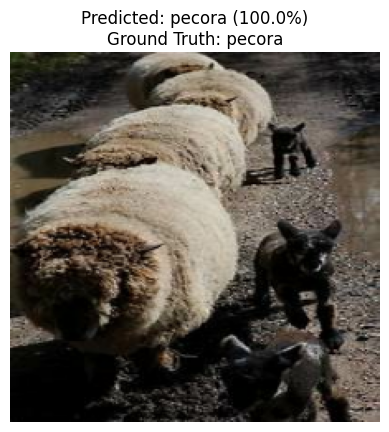

Image 1: Predicted = pecora (100.0%), Ground Truth = pecora
✅
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


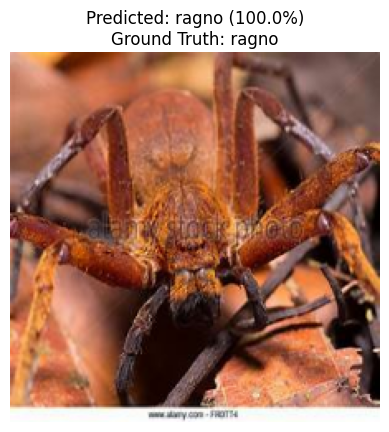

Image 2: Predicted = ragno (100.0%), Ground Truth = ragno
✅
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


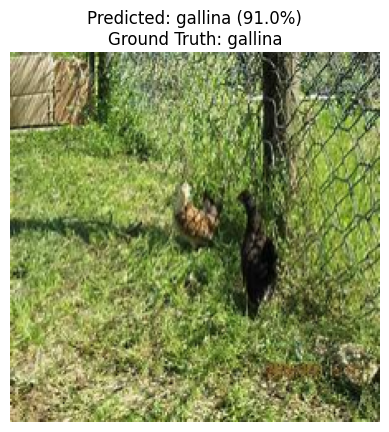

Image 3: Predicted = gallina (91.0%), Ground Truth = gallina
✅
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


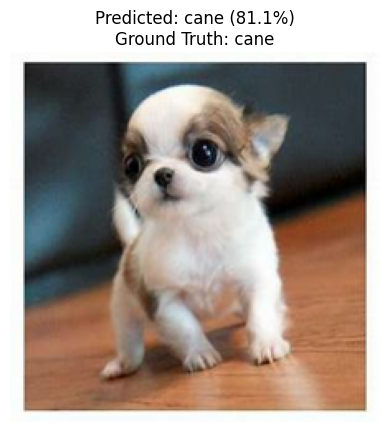

Image 4: Predicted = cane (81.1%), Ground Truth = cane
✅
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


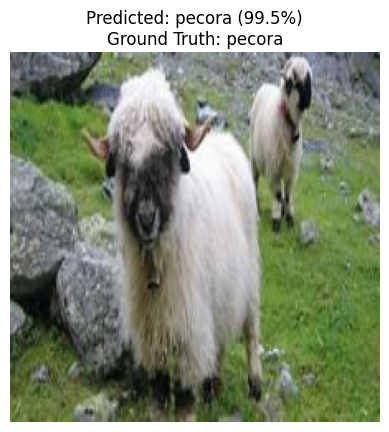

Image 5: Predicted = pecora (99.5%), Ground Truth = pecora
✅
--------------------------------------------------


In [ ]:
for i in range(5):

    img = test_images[i]
    true_label = class_names[test_labels[i]]

    # model expects batch input
    img_input = np.expand_dims(img, axis=0)

    prediction = model.predict(img_input)

    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]

    confidence = np.max(prediction) * 100

    # show image
    plt.imshow(img.astype("uint8"))
    plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)\nGround Truth: {true_label}")
    plt.axis("off")
    plt.show()

    # print format required by assignment
    print(f"Image {i+1}: Predicted = {predicted_label} ({confidence:.1f}%), Ground Truth = {true_label}")
    print("✅" if predicted_label == true_label else "❌")
    print("-"*50)

# Model Performance

The model shows strong overall performance, with decreasing training loss and consistently low validation loss, indicating that it is learning effectively. The validation accuracy is very high (around 95–96%), which means the model performs well on unseen data. Additionally, the gap between training and validation metrics is small, showing that the model generalizes well and is not suffering from overfitting. Overall, the model is stable, reliable, and capable of making accurate predictions.

# Strengths

One major strength of the model is its excellent generalization ability, as seen from the high and stable validation accuracy. It does not overfit, which means it has learned meaningful patterns instead of memorizing the training data. Another strength is the smooth learning behavior, where loss decreases gradually and accuracy increases steadily without sudden fluctuations, indicating stable training. The model also achieves good performance in relatively few epochs, which suggests efficiency in learning.

# Weaknesses

A noticeable weakness is that the training accuracy is lower than the validation accuracy, which may indicate that the model is slightly underfitting or that the training data is more complex or noisy. This means the model has not fully captured all patterns in the training data. Additionally, the improvement in training accuracy is slow and limited, suggesting that the model capacity or training process might not be fully optimized. There may also be a possibility that the dataset is small or not diverse enough.

# Possible Improvements

The model can be improved by increasing training accuracy through techniques such as training for more epochs (if early stopping allows), fine-tuning hyperparameters, or using a slightly more complex model architecture. Improving data quality and increasing dataset size can also help the model learn better patterns. Adjusting regularization techniques like dropout may balance training and validation performance. Data augmentation can further enhance generalization, and learning rate tuning can help achieve faster and more effective convergence.

# Discussion & Reflection

# Advantages of using MobileNet over training from scratch

MobileNet is a pretrained model that already has learned important image features from the ImageNet dataset. This makes it much faster to train compared to building a model from scratch, and it requires less data and computational power. It is also lightweight due to depthwise separable convolutions, making it efficient and suitable for real-world applications like wildlife classification where resources may be limited.

# How data augmentation helped

Data augmentation improved the model by increasing the diversity of training images through transformations such as flipping, rotation, zooming, and brightness changes. This helped the model generalize better by learning from different variations of the same images, reducing overfitting, and making it more robust to real-world conditions like lighting changes and different camera angles.

# What would you improve given more time/compute

With more time and computational resources, I would improve the model by unfreezing and fine-tuning deeper layers of MobileNet to better adapt it to the wildlife dataset. I would also increase the dataset size, try more advanced architectures like EfficientNet, and perform hyperparameter tuning (learning rate, batch size, dropout) to further improve accuracy and reduce errors.